In [7]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = ('C:/Data/Imaging/251224_overlap/fish5/')
rcParams['font.size'] = 10

In [2]:
#load atlas
template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"
template = tifffile.imread(template_path)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_68208\4158968567.py:2: SyntaxWarning: invalid escape sequence '\D'
  template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"


In [68]:
def plot_rainbow(stim_responses, stim_responses_grating):
    region_list =['pretectum', 'tectum', ['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']#['i']
    fig = plt.figure(dpi=240, figsize=(20, 10))
    gs = gridspec.GridSpec(len(region_list), 4, figure=fig)
    ax_imshow_all = fig.add_subplot(gs[:, 0])

    #only plot visually responsive neurons that have been somewhat barrcoded
    barred = set(stim_responses.index[(stim_responses.filter(like="barred_").any(axis=1)) & (stim_responses_grating["DSI2"] >0)])
    barred_hist = set(stim_responses.index[(stim_responses.filter(like="barred_").any(axis=1)) & (stim_responses_grating["DSI2"] > 0)])

    for i, r in enumerate(region_list):
        if type(r) == list:
            region_n = set(stim_responses.index[stim_responses['regions'].apply(lambda x: any(ri in x for ri in r))])
        else:
            region_n =set(stim_responses.index[stim_responses['regions'].apply(lambda x: r in x)])#set(stim_responses.index)#
        barred_r = list(region_n & barred)
        barred_hist_r = list(region_n & barred_hist)

        #manage figure space
        ax_polar_all = fig.add_subplot(gs[i, 1], polar = True)
        ax_polar_all.set_theta_offset(np.pi/2)
        ax_polar_all.set_ylim([i, 1])
        ax_polar_all.set_theta_direction(-1)
        ax_heat = fig.add_subplot(gs[i, 2], polar = True)
        ax_heat.set_theta_offset(np.pi/2)
        ax_heat.set_theta_direction(-1)

        ax_hist = fig.add_subplot(gs[i, 3])
        #
        #color: tuned angles
        colors = stim_responses.loc[barred_r, 'dir']
        colors = [utils.angle_to_rgba(c, 1, 1) for c in colors]
        #alpha: dsi
        alphas = stim_responses.loc[barred_r, 'DSI2']#use grating alpha so it still would show up
        alphas = [i if not np.isnan(i) else 0 for i in alphas]
        #ax_imshow_all.scatter(stim_responses.loc[barred_r, 'xpos'], stim_responses.loc[barred_r, 'ypos'], c = colors, s = .01, alpha = np.clip(alphas, 0, 1), marker = '.')
        #
        #plot vector plot
        dirs_rad = np.deg2rad(stim_responses.loc[barred_r, 'dir'].values)
        radii = stim_responses.loc[barred_r, 'DSI2'].values
        # ax_polar_all.scatter(dirs_rad, radii, c=colors, alpha=0.7, s=5, marker = '.')
        ax_polar_all.set_ylim([0, 1])
        ax_polar_all.set_axis_off()
        #plot it across all neurons
        #ax_imshow_all.imshow(template[160], cmap = 'gray', vmax = 400)
        ax_imshow_all.set_axis_off()

        #plot heatmap
        theta_bins = np.linspace(-np.pi, np.pi, 73)
        r_bins = np.linspace(0, 1, 10)
        H, theta_edges, r_edges = np.histogram2d(dirs_rad, radii, bins=[theta_bins, r_bins])
        H = H / H.sum() * 100
        T, R = np.meshgrid(theta_edges, r_edges)
        #ax_heat.pcolormesh(T, R, H.T, vmin = 0, vmax = 0.5)
        ax_heat.set_axis_off()
        #
        #plot histogram
        hist_data = stim_responses.loc[barred_hist_r]
        # bin DSI2 into 0.1 steps
        bins = np.arange(0, 1.1, 0.05)
        hist_data['DSI2'] = pd.to_numeric(hist_data['DSI2'], errors='coerce')
        hist_data = hist_data.dropna(subset=['DSI2'])
        hist_data['DSI_bin'] = pd.cut(hist_data['DSI2'], bins=bins, include_lowest=True)
        hist_data['DSI_bin'] = hist_data['DSI_bin'].apply(lambda x: x.left + (x.right - x.left)/2)
        # compute mean probability per bin for each fish
        bin_stats = hist_data.groupby(['DSI_bin', 'fish_id'], observed = False).size().reset_index(name='count')
        p = bin_stats.groupby('fish_id')['count'].transform(lambda x: x / x.sum())
        bin_stats['prob'] = p.groupby(bin_stats['fish_id']).cumsum()
        # plot mean across fish with confidence interval
        sns.lineplot(data=bin_stats,x='DSI_bin',y= 'prob', errorbar='se',ax=ax_hist)
        ax_hist.set_ylim([0, 1])
        ax_hist.spines[['top', 'right']].set_visible(False)
    return fig

C:\Users\Zichen\AppData\Local\Temp\ipykernel_68208\97373577.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_polar_all.set_ylim([i, 1])


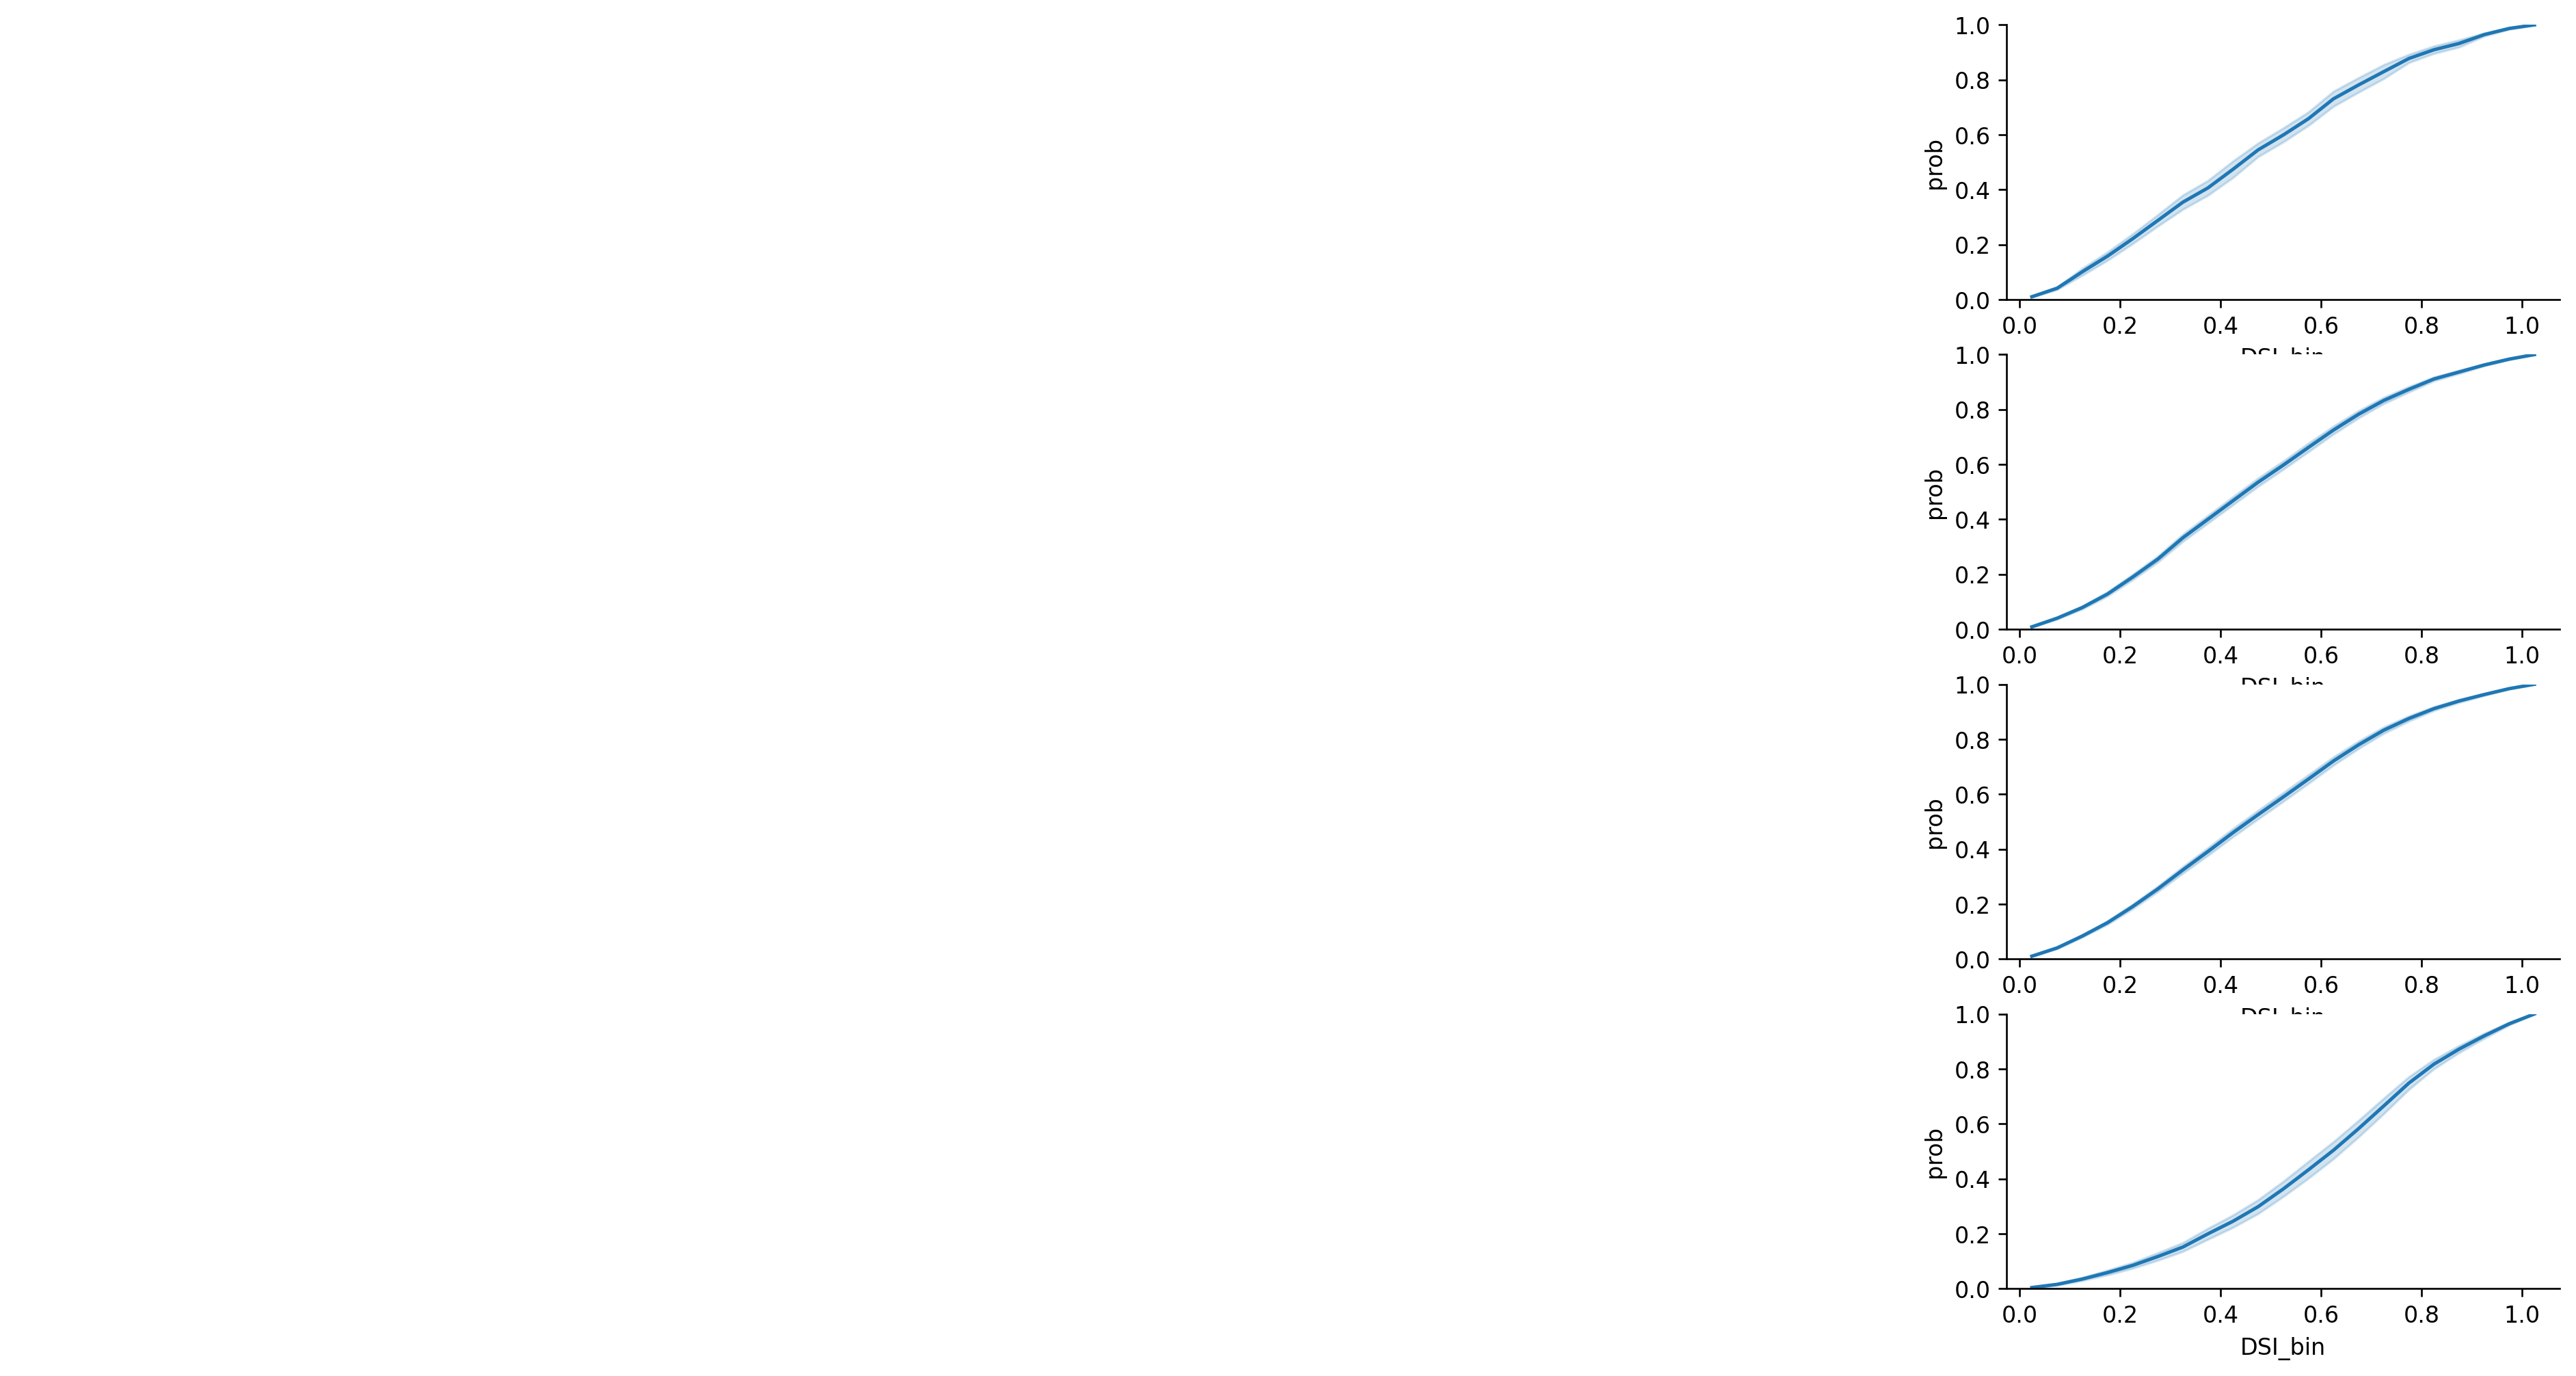

In [69]:
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]

grating_responses = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//grating_responses_delayed.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos_all.csv', index_col = 0,  converters={"regions": lambda x: [] if (pd.isna(x) or str(x)=="[]" or str(x) == "") else ast.literal_eval(x)})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        #neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_response.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
    grating_responses.append(grating_response)
grating_responses = pd.concat(grating_responses).reset_index(drop = True)
fig = (plot_rainbow(grating_responses, grating_responses))
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_Imaging//dsi_delayed.svg")
plt.show()
plt.close()

C:\Users\Zichen\AppData\Local\Temp\ipykernel_68208\97373577.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_polar_all.set_ylim([i, 1])


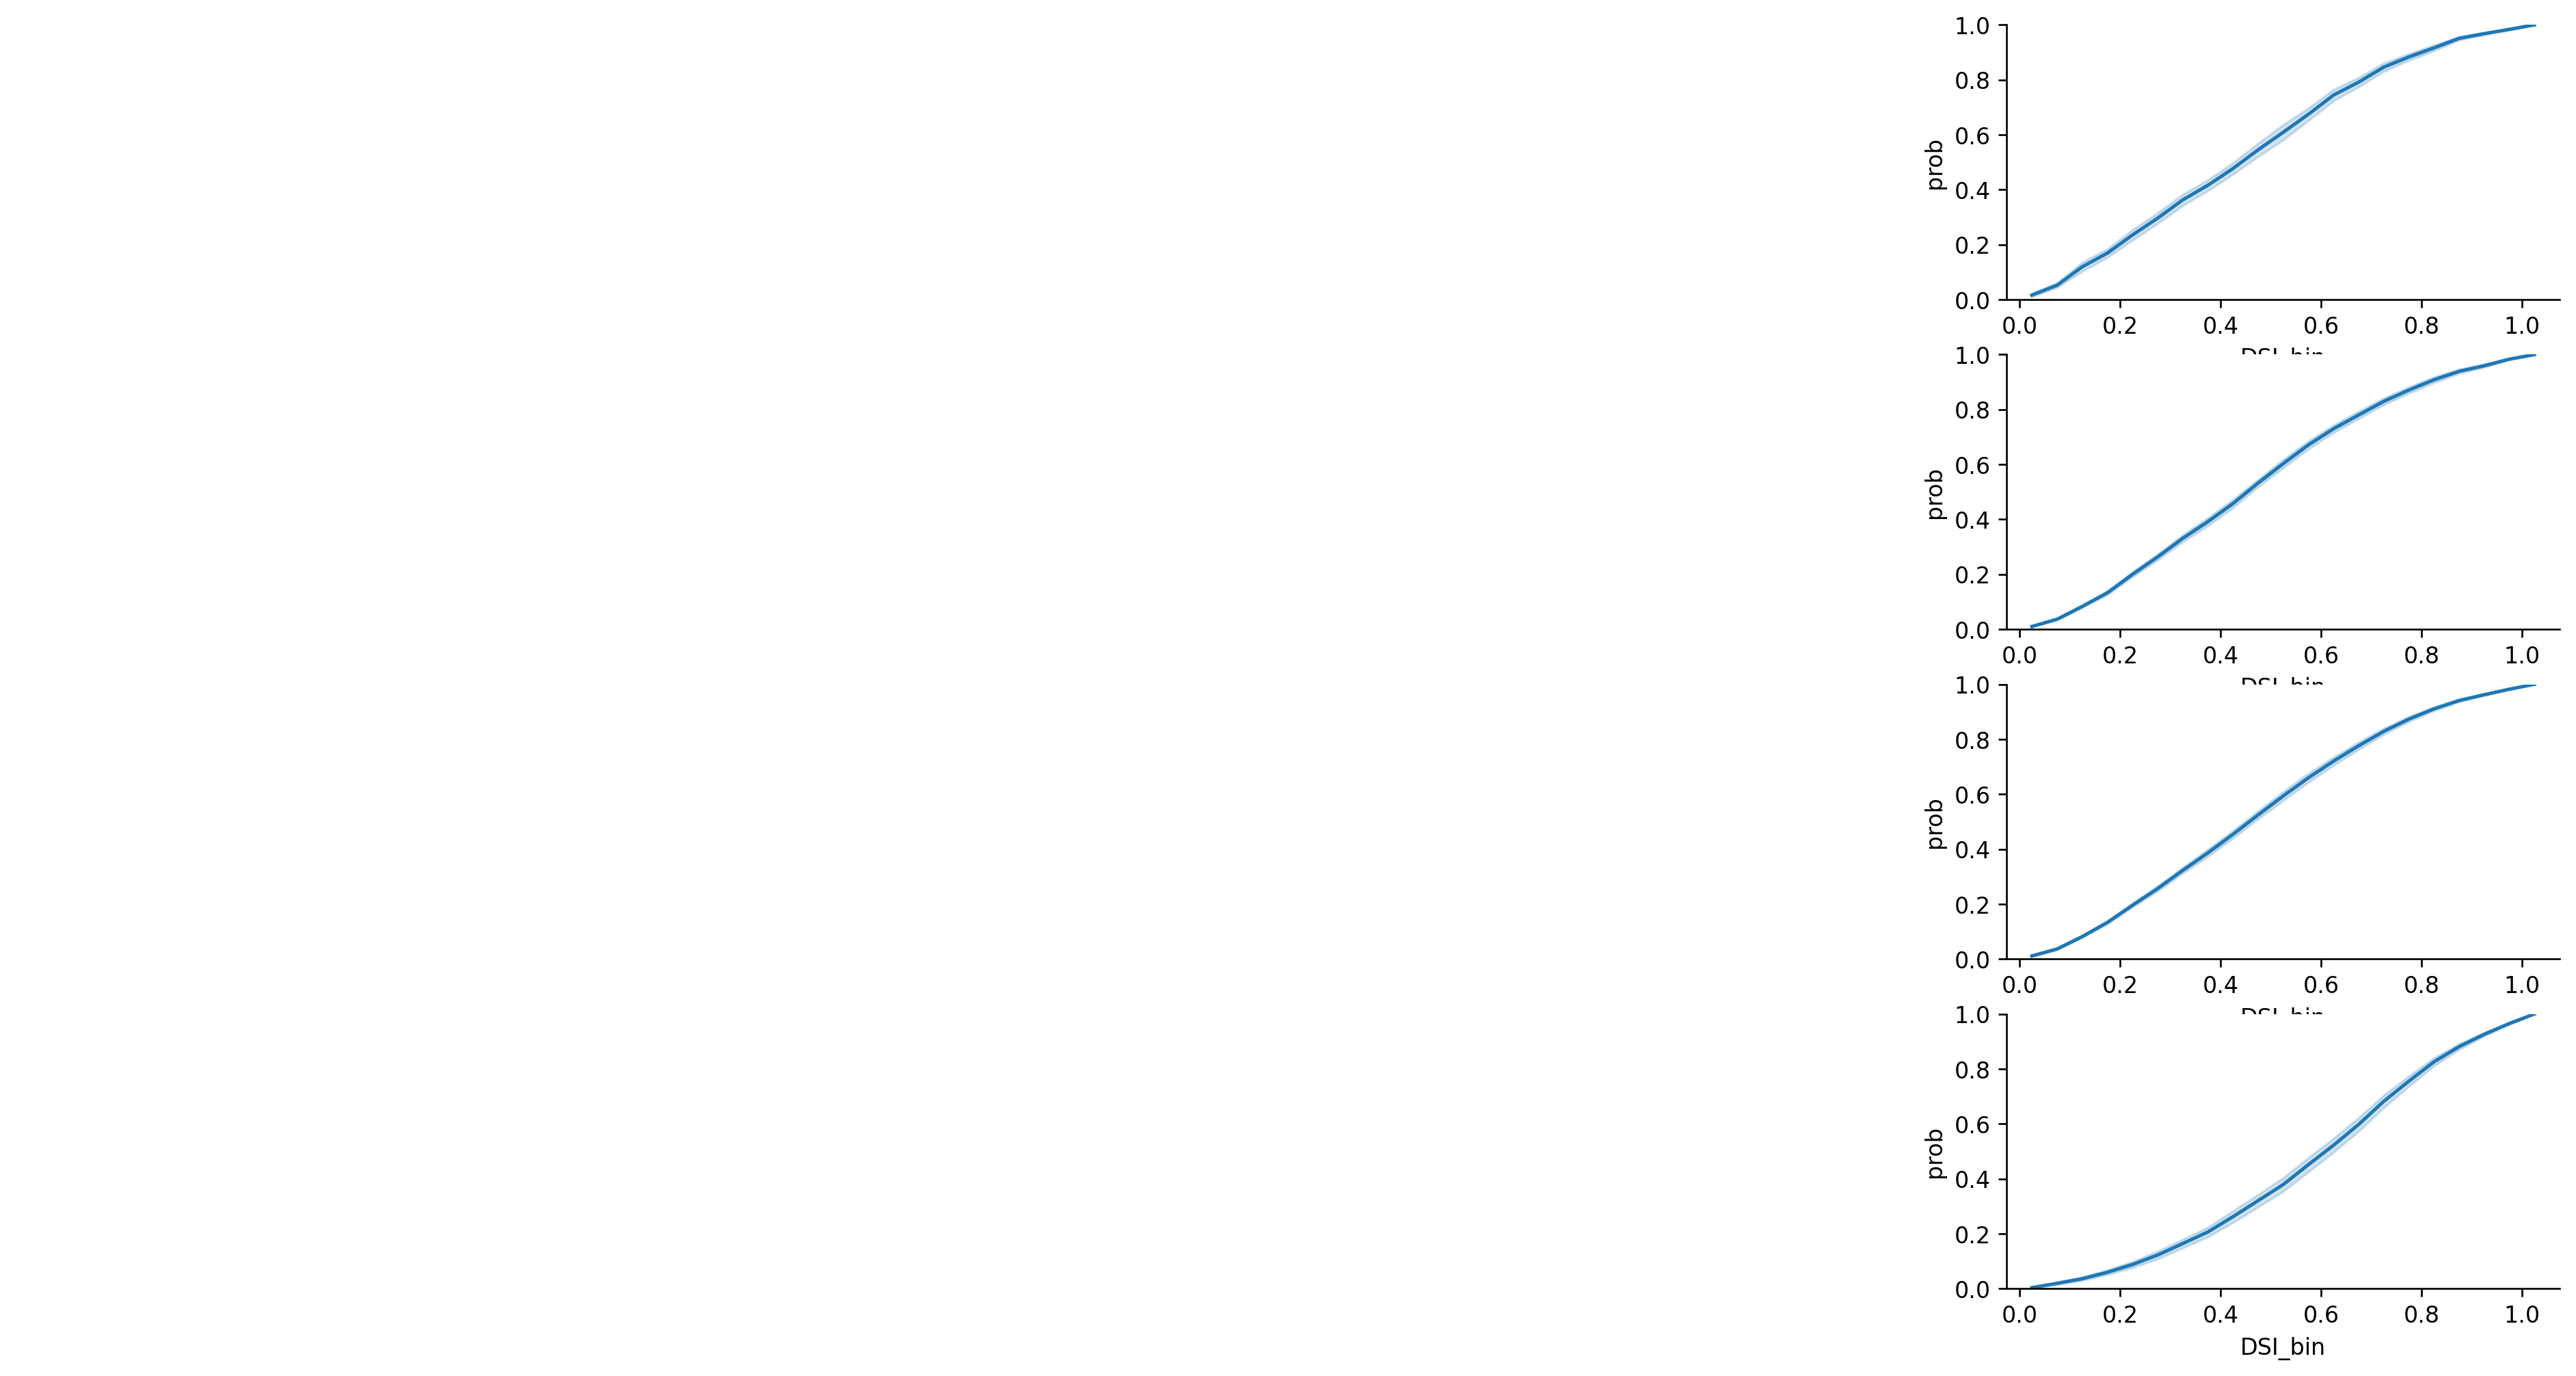

In [70]:
grating_responses1 = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//dot_lgrating_responses_delayed.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos_all.csv', index_col = 0, converters={"regions": lambda x: [] if (pd.isna(x) or str(x)=="[]" or str(x) == "") else ast.literal_eval(x)})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_responses1.append(grating_response)
grating_responses1 = pd.concat(grating_responses1).reset_index()
fig = plot_rainbow(grating_responses1, grating_responses)
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//dsi_dotl_delayed.svg")

plt.show()
plt.close()

C:\Users\Zichen\AppData\Local\Temp\ipykernel_68208\97373577.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_polar_all.set_ylim([i, 1])


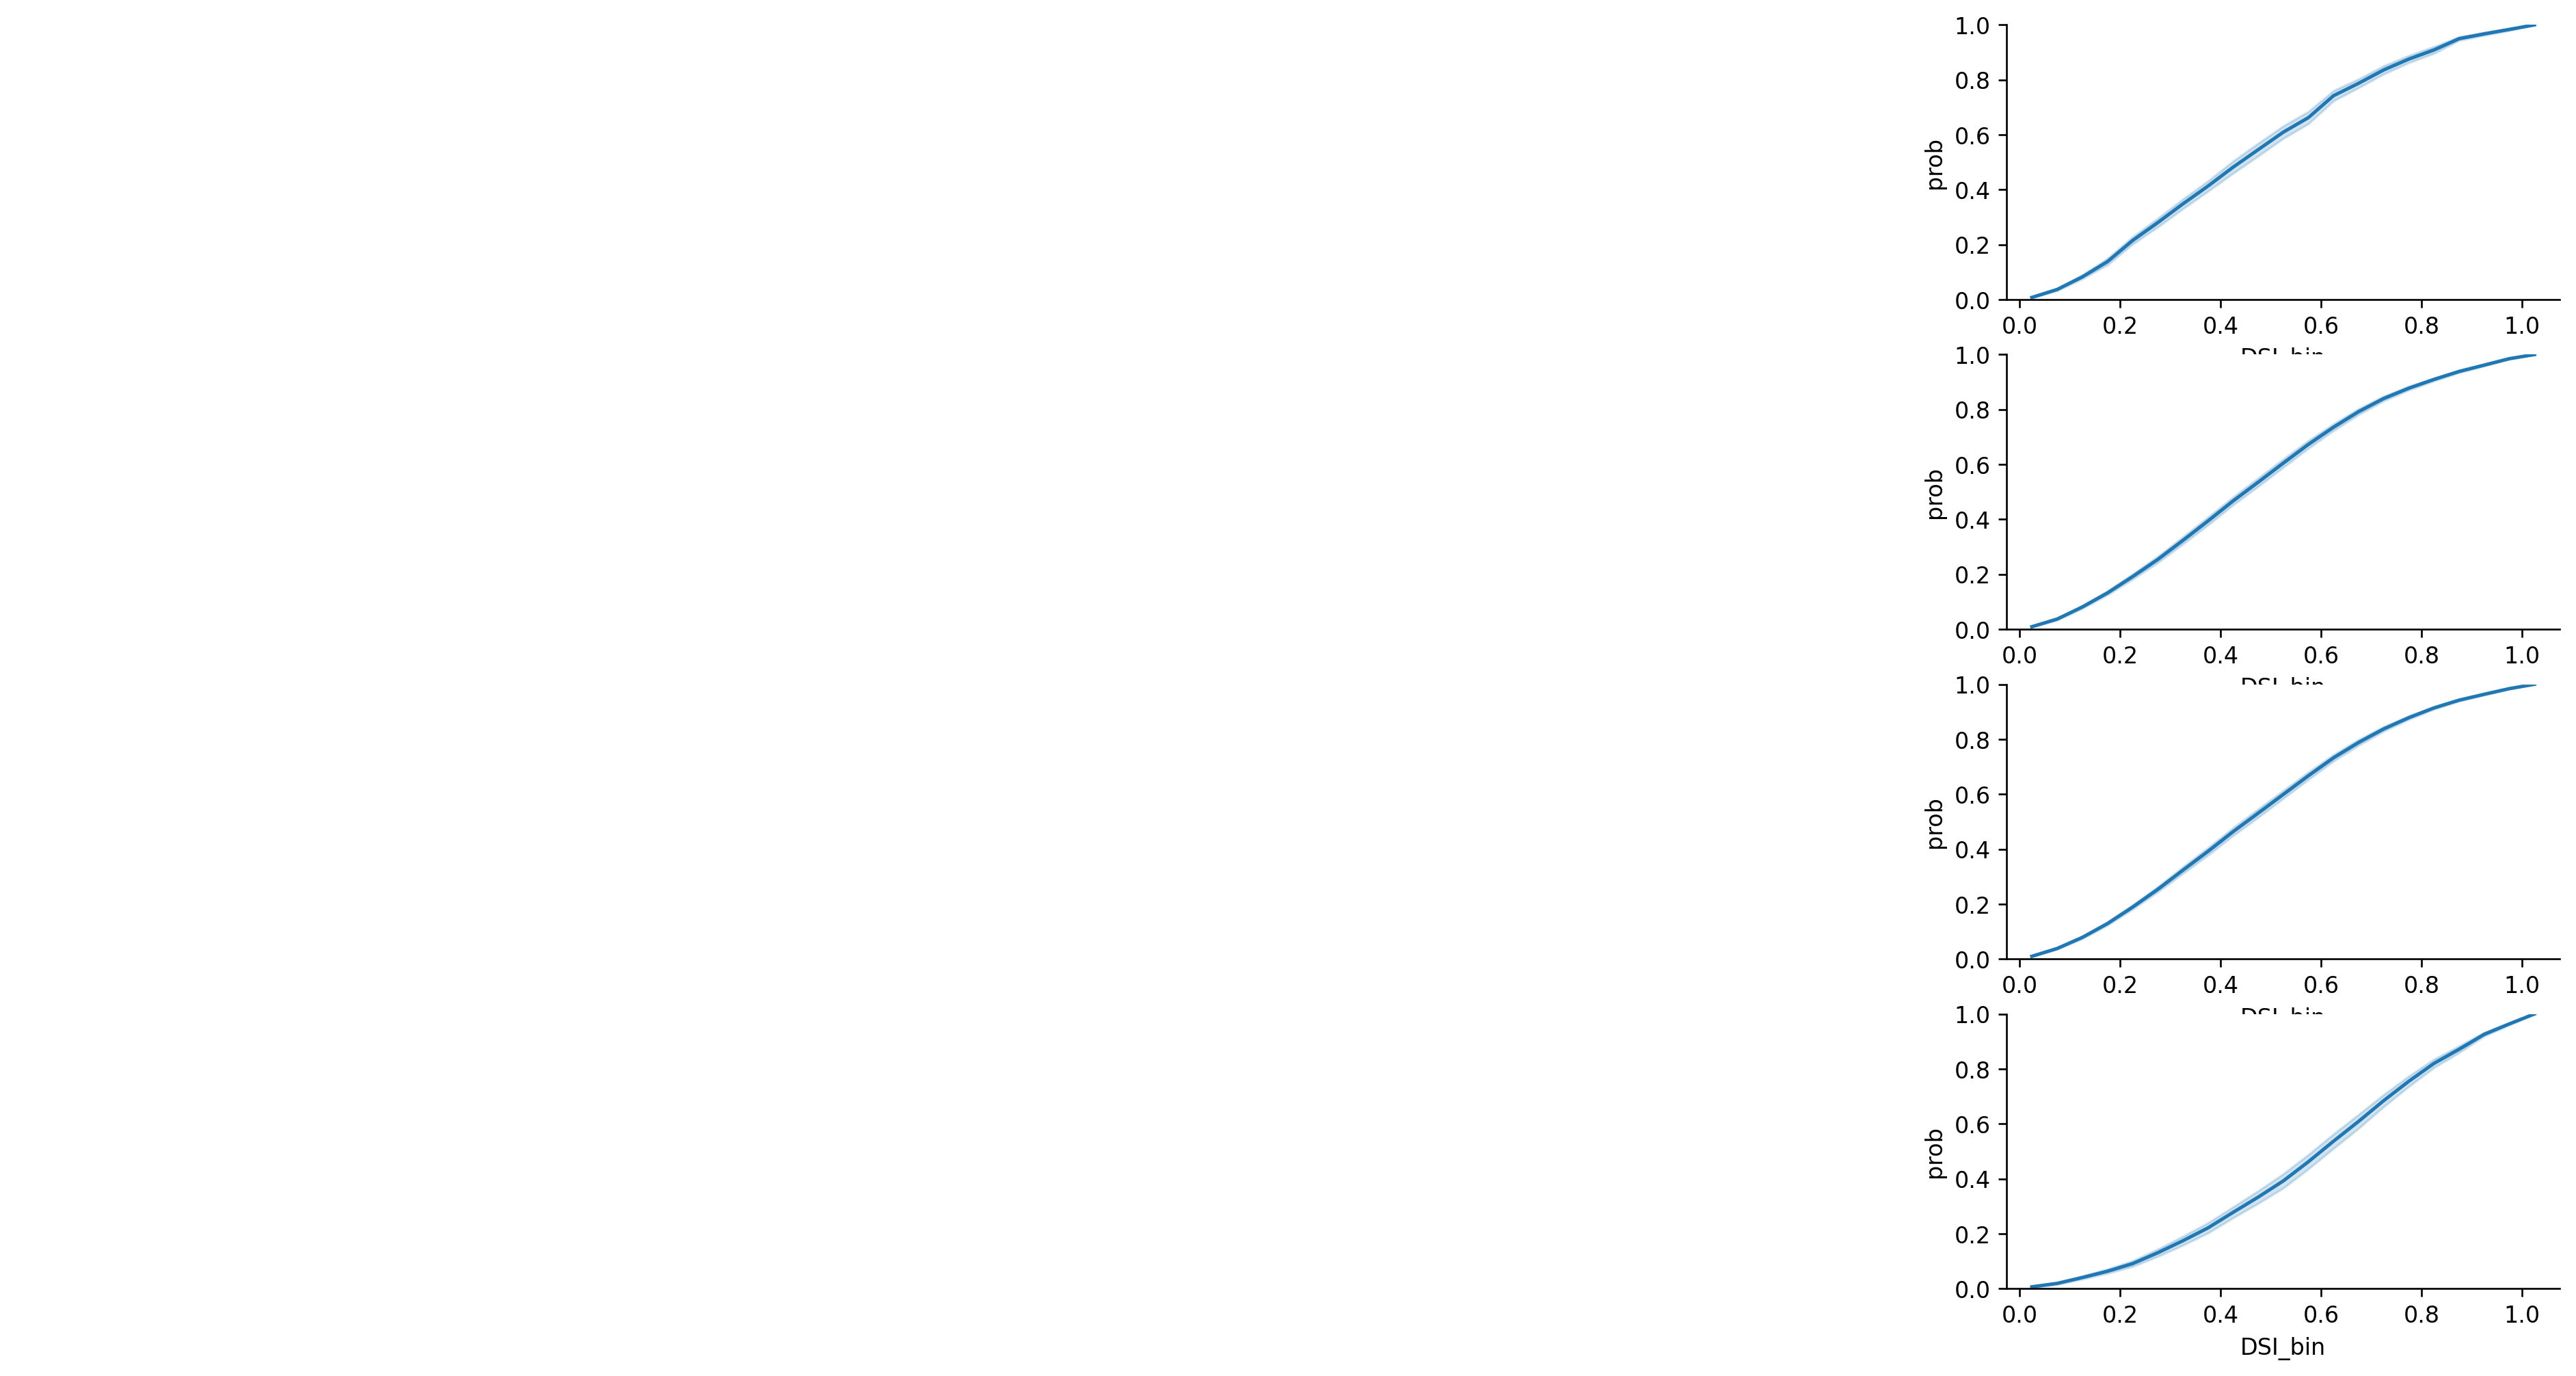

In [71]:
grating_responses2 = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//dot_rgrating_responses_delayed.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos_all.csv', index_col = 0, converters={"regions": lambda x: [] if (pd.isna(x) or str(x)=="[]" or str(x) == "") else ast.literal_eval(x)})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_responses2.append(grating_response)
grating_responses2 = pd.concat(grating_responses2).reset_index()
fig = plot_rainbow(grating_responses2, grating_responses)
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//dsi_dotr_delayed.svg")

plt.show()
plt.close()

In [254]:
grating_responses.columns

Index(['backward', 'forward', 'left', 'right', 'DSI1', 'dir', 'DSI2',
       'barred_backward', 'barred_forward', 'barred_left', 'barred_right',
       'xpos', 'ypos', 'zpos', 'zpos_atlas', 'regions', 'fish_id'],
      dtype='object')

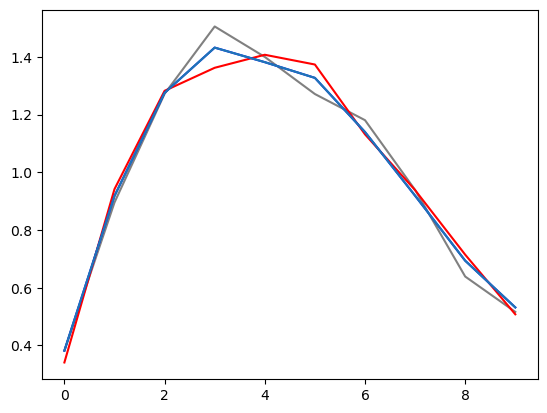

In [431]:
fig, ax = plt.subplots(1, 1)
region = ['tectum']#['pretectum', 'tectum', ['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']#['i']
g = []
g1 =[ ]
g2 = []
for fish in grating_responses.fish_id.unique():
    gr = grating_responses[(grating_responses.fish_id == fish)& (grating_responses.regions.apply(lambda x: any(ri in x for ri in region)))]
    gr1 = grating_responses1[(grating_responses1.fish_id == fish)& (grating_responses1.regions.apply(lambda x: any(ri in x for ri in region)))]
    gr2 = grating_responses2[(grating_responses2.fish_id == fish) & (grating_responses2.regions.apply(lambda x: any(ri in x for ri in region)))]
    if len(gr) > 0: a, bin_edges = np.histogram(gr[gr['regions'].apply(lambda x: any(ri in x for ri in region))].DSI2, range = (0, 1), bins = 10, density = True)
    if len(gr1) > 0 : b, _= np.histogram(gr1[gr1['regions'].apply(lambda x: any(ri in x for ri in region))].DSI2, range = (0, 1), bins = 10, density = True )
    if len(gr2) >0: c, _= np.histogram(gr2[gr2['regions'].apply(lambda x: any(ri in x for ri in region))].DSI2, range = (0, 1),  bins = 10, density = True )
    g.append(a)
    g1.append(b)
    g2.append(c)
g = np.mean(np.array(g).astype(float), axis = 0)
g1 = np.mean(np.array(g1).astype(float), axis = 0)
g2 = np.mean(np.array(g2).astype(float), axis = 0)
ax.plot(g, c = 'grey')
ax.plot(g1, c = 'red')
ax.plot(g2, c = 'blue')
ax.plot(g2)

plt.show()
plt.close()

In [257]:
# Difference in DSI (positive = suppression/decrease)
dsi_change = grating_responses.DSI2 - np.mean([grating_responses2.DSI2, grating_responses1.DSI2], axis = 0)

# Keep only suppressed cells
suppressed = grating_responses.copy()
suppressed['dsi_change'] = dsi_change
suppressed = suppressed[(suppressed['dsi_change'] > 0) & (suppressed['DSI2']>= 0.5)]

# Expand the region lists into separate rows
# Example:
# ['tectum', 'habenula'] -> two rows
region_df = suppressed[['regions', 'dsi_change']].explode('regions')

# Remove empty / NaN regions
region_df = region_df[
    region_df['regions'].notna() &
    (region_df['regions'] != '')
]

# Average suppression per region
region_suppression = (
    region_df
    .groupby('regions')['dsi_change']
    .agg(['mean', 'median', 'count', 'std', 'sem'])
    .sort_values('mean', ascending=False)
)
region_suppression = region_suppression[region_suppression['count'] >= 10]

print(region_suppression.head(20))

                                                     mean    median  count  \
regions                                                                      
inferior_dorsal_medulla_oblongata_stripe_2&3    60.993662  0.465022    655   
superior_dorsal_medulla_oblongata_stripe_2&3    31.331098  0.324095   1256   
inferior_dorsal_medulla_oblongata               23.812567  0.427940   1888   
inferior_medulla_oblongata                      19.473554  0.404076   2407   
retinal_arborization_field_7                    15.325883  0.331407     43   
medial_octavolateralis_nucleus                  15.264122  0.504191    833   
superior_dorsal_medulla_oblongata               14.632993  0.355284   4012   
medulla_oblongata                               11.938949  0.370672  10893   
superior_medulla_oblongata                      11.616537  0.347266   5932   
rhombencephalon_(hindbrain)                     11.553018  0.383784  12426   
intermediate_dorsal_medulla_oblongata_stripe_5  10.562032  0.399

In [223]:
region_suppression.reset_index(drop = False, inplace = True)
region_suppression[region_suppression.regions == 'pretectum']

,regions,mean,median,count,std,sem
61,pretectum,2.955593,0.276875,3922,17.781138,0.283926


In [224]:
region_suppression[region_suppression.regions == 'nucleus_isthmi']

,regions,mean,median,count,std,sem
54,nucleus_isthmi,3.341794,0.301112,1585,19.088112,0.479456


In [225]:
region_suppression[region_suppression.regions == 'intermediate_medulla_oblongata']

,regions,mean,median,count,std,sem
5,intermediate_medulla_oblongata,17.600489,0.34266,2526,578.821035,11.516689


In [515]:
def plot_rainbow2(stim_responses, stim_responses1, stim_responses2):
    fig = plt.figure(dpi=240, figsize=(10, 10))
    gs = gridspec.GridSpec(3, 2, figure=fig)

    #only plot visually responsive neurons that have been somewhat barrcoded
    barred_r = list(set(stim_responses.index[(stim_responses.filter(like="barred_").any(axis=1)) & (stim_responses["DSI2"] >0)]))

    for n, (dot_stim, stim_responses_dot) in enumerate(zip(['dot_l', 'dot_r'], [stim_responses1, stim_responses2])):
        #manage figure space
        ax_dot = fig.add_subplot(gs[0, n])
        ax_polar_all = fig.add_subplot(gs[1, n], polar = True)
        ax_polar_all.set_theta_offset(np.pi/2)
        ax_polar_all.set_ylim([0, 1])
        ax_polar_all.set_theta_direction(-1)
        ax_heat = fig.add_subplot(gs[2, n], polar = True)
        ax_heat.set_theta_offset(np.pi/2)
        ax_heat.set_ylim([0, 1])
        ax_heat.set_theta_direction(-1)

        #color: tuned angles
        colors_pre = np.subtract(stim_responses_dot.loc[barred_r, 'dir'], stim_responses.loc[barred_r, 'dir'])
        colors = [utils.angle_to_rgba(c, 1, 1) for c in colors_pre]
        #alpha: dsi
        alphas = np.subtract(stim_responses_dot.loc[barred_r, 'DSI2'], stim_responses.loc[barred_r, 'DSI2'])#pos: grating>dot; neg: dot>grating
        alphas = [i if not np.isnan(i) else 0 for i in alphas]
        alphas = np.clip(np.subtract(1, np.abs(alphas)), 0, 1)#np.clip(np.divide(np.add(alphas, 1),2), 0, 1)
        ax_dot.set_title("DSI maintain  in overlap")
        ax_dot.scatter(stim_responses.loc[barred_r, 'xpos'], stim_responses.loc[barred_r, 'ypos'], c = colors, alpha = alphas, s = .0005, marker = '.')

        #plot vector plot
        dirs_rad = np.deg2rad(colors_pre)
        radii = alphas
        ax_polar_all.scatter(dirs_rad, radii, c=colors, alpha=1, s=1, marker = '.')
        ax_polar_all.set_ylim([0, 1])
        ax_polar_all.set_axis_off()
        #plot it across all neurons
        ax_dot.imshow(template[160], cmap = 'gray', vmax = 1500)
        ax_dot.set_axis_off()

        #plot heatmap
        theta_bins = np.linspace(-np.pi, np.pi, 73)
        r_bins = np.linspace(0, 1, 10)
        H, theta_edges, r_edges = np.histogram2d(dirs_rad, radii, bins=[theta_bins, r_bins])
        H = H / H.sum() * 100
        T, R = np.meshgrid(theta_edges, r_edges)
        ax_heat.pcolormesh(T, R, H.T, vmin = 0, vmax = 5)
        ax_heat.set_axis_off()
        ax_heat.axvline(0, linewidth = 1 ,linestyle = '--', color = 'maroon')

    return fig

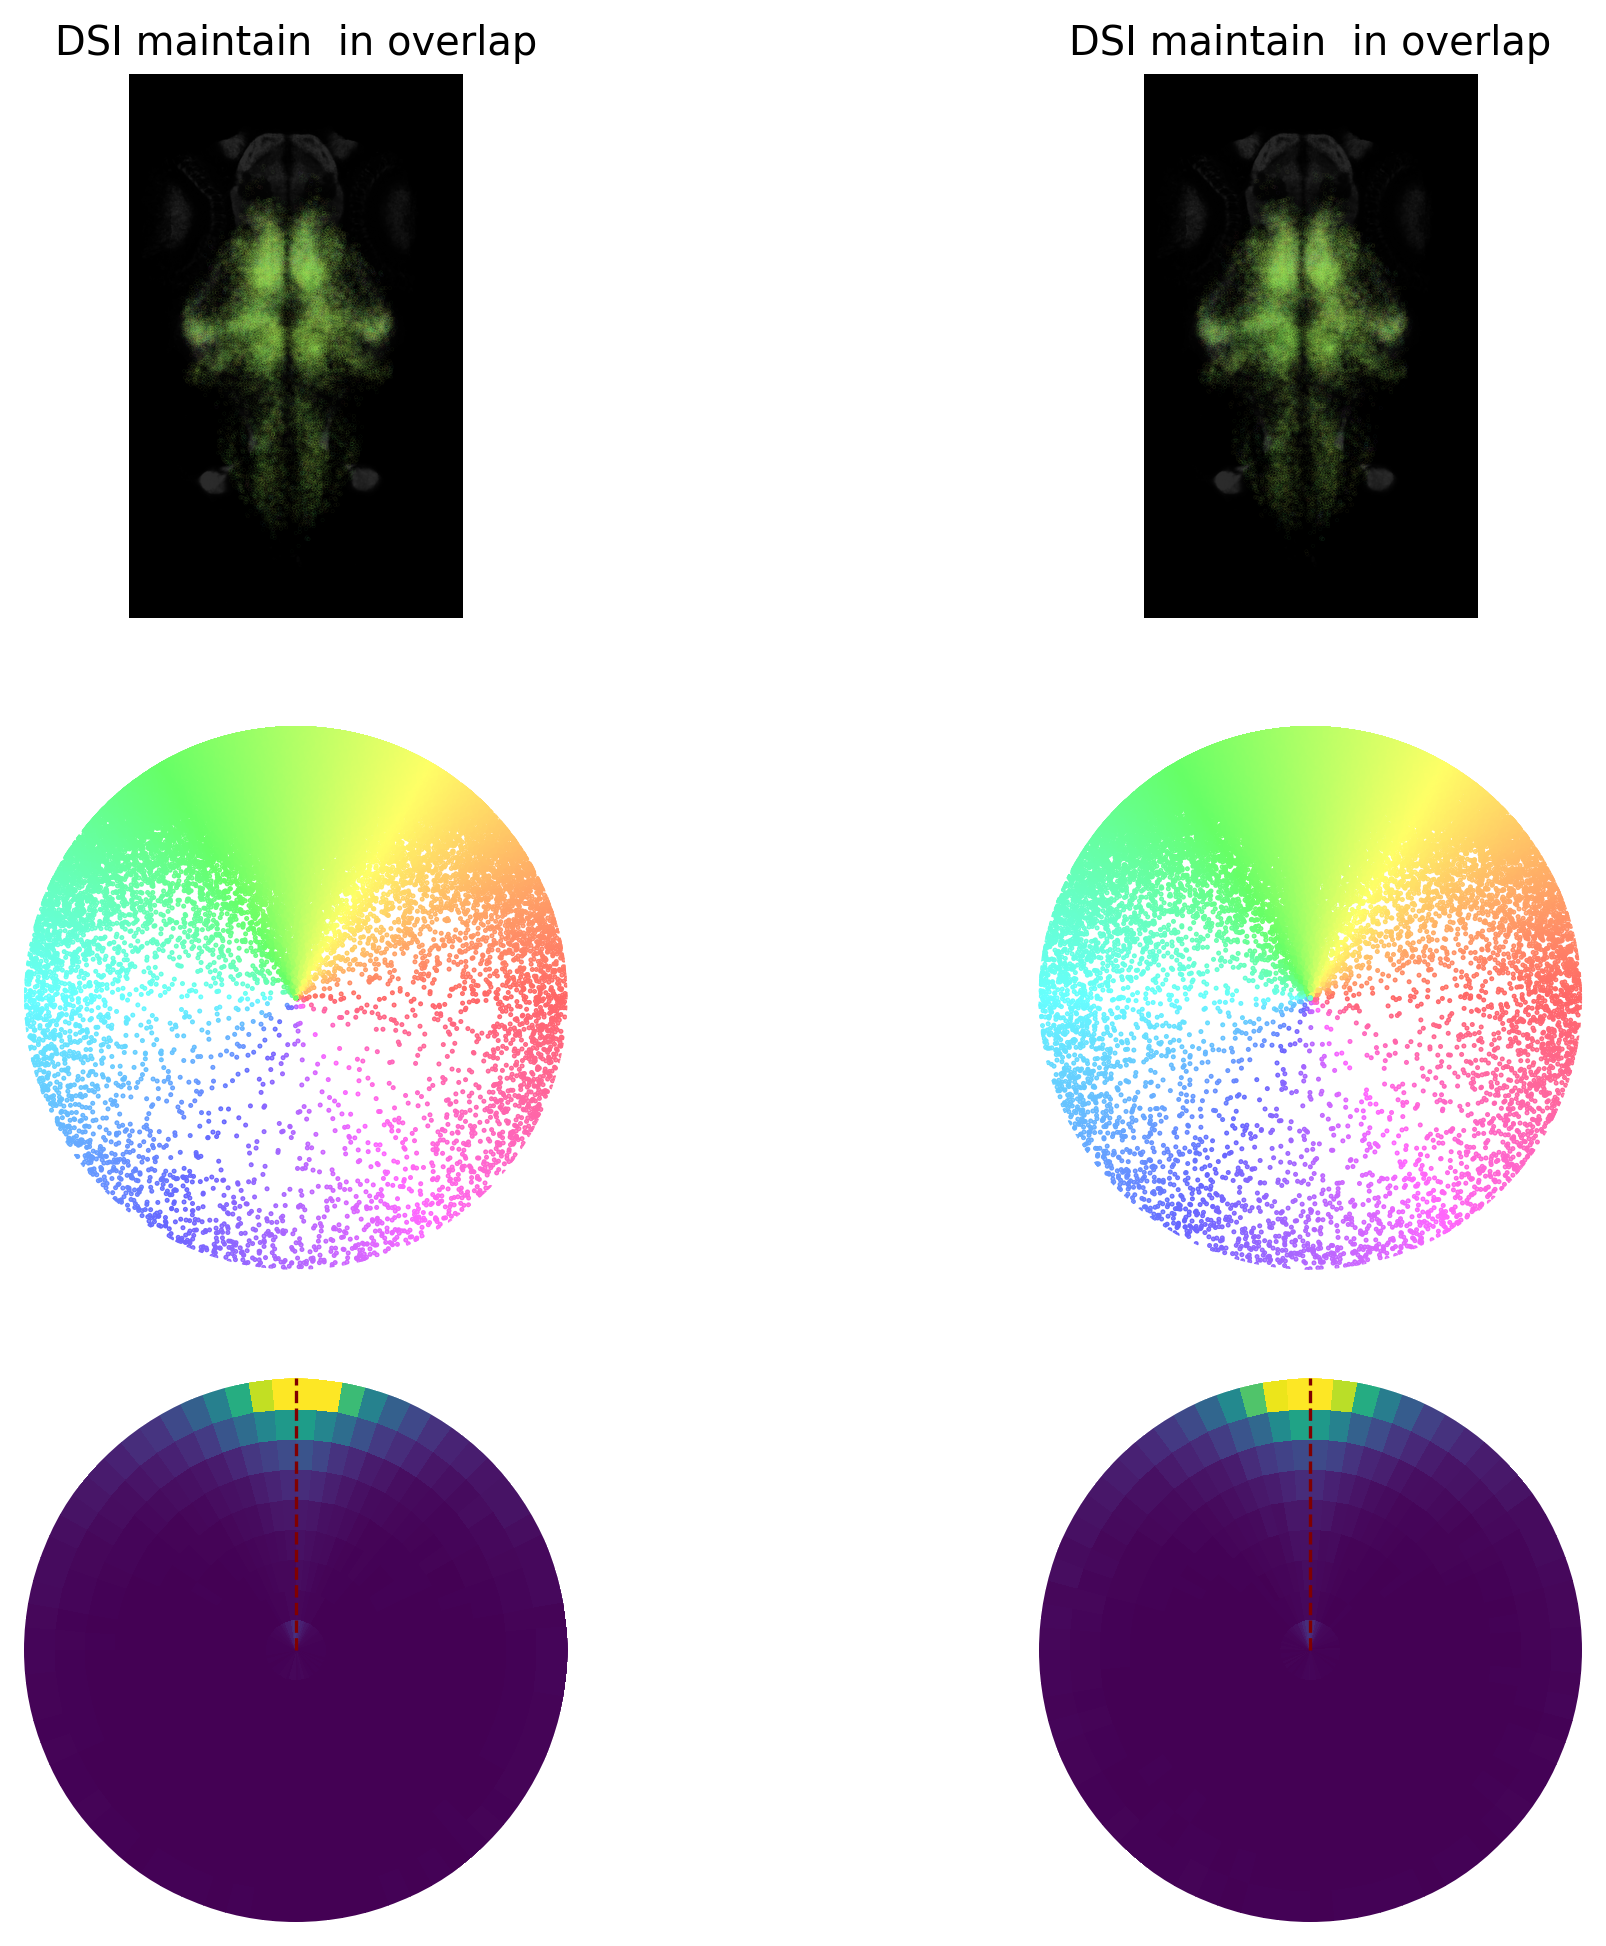

In [516]:
plot_rainbow2(grating_responses, grating_responses1, grating_responses2)
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//dsi_change_maintain.png")
plt.show()
plt.close()
